In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize


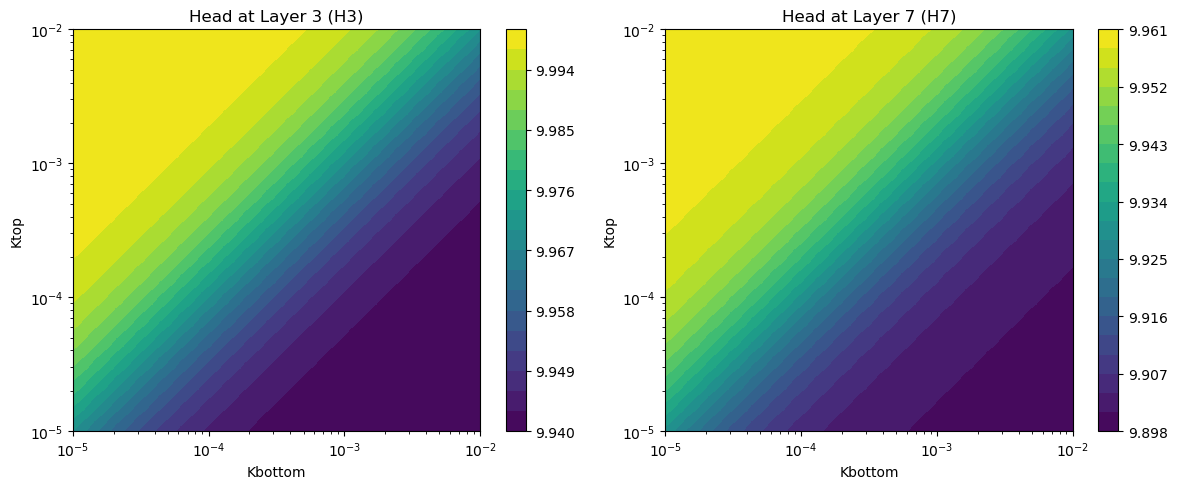

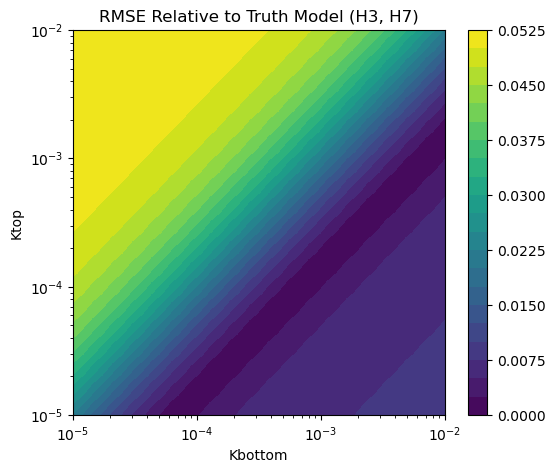

In [2]:
# --- Parameters ---
n_layers = 10
z = np.linspace(0, 1, n_layers + 1)  # 11 nodes, 10 layers
dz = z[1] - z[0]

H_top = 10.0   # fixed head top boundary
H_bottom = 0.0 # fixed head bottom boundary

# --- Functions ---
def steady_state_head(K_layers, H_top, H_bottom):
    """Compute steady-state heads for 1D vertical flow with piecewise-constant K."""
    n = len(K_layers)
    dz = 1.0 / n
    # Compute equivalent conductance for the column
    R_total = np.sum(1.0 / (K_layers * dz))
    q = (H_top - H_bottom) / R_total  # constant flux

    h = np.zeros(n + 1)
    h[0] = H_top
    for i in range(n):
        dh = q * dz / K_layers[i]
        h[i + 1] = h[i] - dh
    return h

# --- Model grid of K values ---
Ktop_values = np.logspace(-5, -2, 20)
Kbottom_values = np.logspace(-5, -2, 20)

H3 = np.zeros((20, 20))
H7 = np.zeros((20, 20))

for i, Ktop in enumerate(Ktop_values):
    for j, Kbottom in enumerate(Kbottom_values):
        K_layers = np.array([Ktop]*5 + [Kbottom]*5)
        h = steady_state_head(K_layers, H_top, H_bottom)
        H3[i, j] = h[3]
        H7[i, j] = h[7]

# --- Contour plots ---
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

cs1 = axs[0].contourf(Kbottom_values, Ktop_values, H3, levels=20)
axs[0].set_xscale('log')
axs[0].set_yscale('log')
axs[0].set_xlabel('Kbottom')
axs[0].set_ylabel('Ktop')
axs[0].set_title('Head at Layer 3 (H3)')
fig.colorbar(cs1, ax=axs[0])

cs2 = axs[1].contourf(Kbottom_values, Ktop_values, H7, levels=20)
axs[1].set_xscale('log')
axs[1].set_yscale('log')
axs[1].set_xlabel('Kbottom')
axs[1].set_ylabel('Ktop')
axs[1].set_title('Head at Layer 7 (H7)')
fig.colorbar(cs2, ax=axs[1])

plt.tight_layout()
plt.show()

# --- Truth model ---
Ktop_true = 3e-4
Kbottom_true = 2e-3
K_layers_true = np.array([Ktop_true]*5 + [Kbottom_true]*5)
h_true = steady_state_head(K_layers_true, H_top, H_bottom)
H3_true, H7_true = h_true[3], h_true[7]

# --- RMSE surface ---
RMSE = np.zeros((20, 20))
for i in range(20):
    for j in range(20):
        RMSE[i, j] = np.sqrt(((H3[i, j] - H3_true)**2 + (H7[i, j] - H7_true)**2) / 2)

plt.figure(figsize=(6, 5))
cs3 = plt.contourf(Kbottom_values, Ktop_values, RMSE, levels=20)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Kbottom')
plt.ylabel('Ktop')
plt.title('RMSE Relative to Truth Model (H3, H7)')
plt.colorbar(cs3)
plt.show()


True H3: 9.9478, Observed H3: 10.0467
True H7: 9.9078, Observed H7: 9.8804


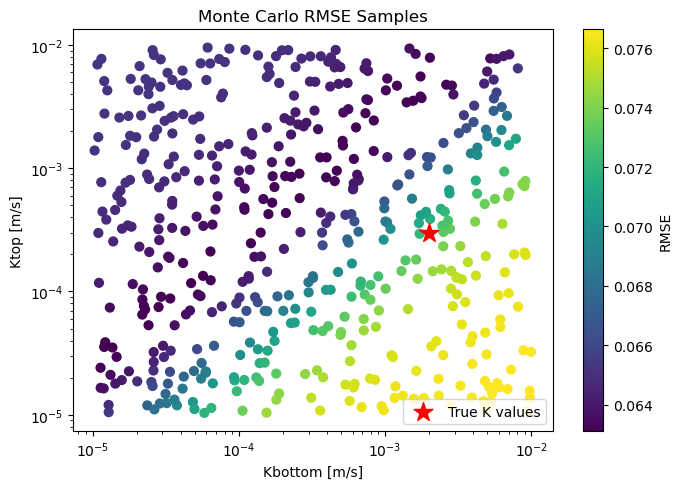

Optimization terminated successfully.
         Current function value: 0.063111
         Iterations: 57
         Function evaluations: 110

--- Downhill Simplex Results ---
True values:     Ktop=3.00e-04, Kbottom=2.00e-03
Estimated values: Ktop=1.84e-04, Kbottom=6.94e-05
Final RMSE: 0.06311


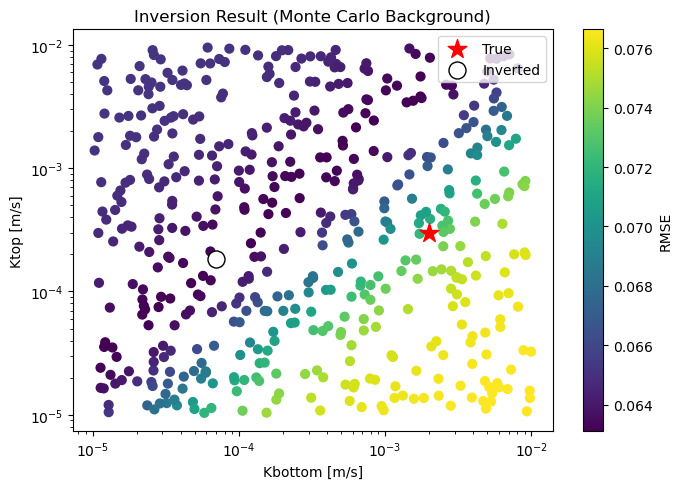

In [3]:
# --- Core steady-state model ---
def steady_state_head(K_layers, H_top, H_bottom):
    n = len(K_layers)
    dz = 1.0 / n
    R_total = np.sum(1.0 / (K_layers * dz))
    q = (H_top - H_bottom) / R_total
    h = np.zeros(n + 1)
    h[0] = H_top
    for i in range(n):
        dh = q * dz / K_layers[i]
        h[i + 1] = h[i] - dh
    return h

# --- Fixed problem setup ---
H_top, H_bottom = 10.0, 0.0
n_layers = 10

# Truth model
Ktop_true = 3e-4
Kbottom_true = 2e-3
K_layers_true = np.array([Ktop_true]*5 + [Kbottom_true]*5)
h_true = steady_state_head(K_layers_true, H_top, H_bottom)
H3_true, H7_true = h_true[3], h_true[7]

# Add synthetic measurement noise
np.random.seed(42)
noise_level = 0.02  # ±2% noise
H3_obs = H3_true * (1 + np.random.normal(0, noise_level))
H7_obs = H7_true * (1 + np.random.normal(0, noise_level))

print(f"True H3: {H3_true:.4f}, Observed H3: {H3_obs:.4f}")
print(f"True H7: {H7_true:.4f}, Observed H7: {H7_obs:.4f}")

# --- RMSE objective function ---
def rmse_objective(Kpair):
    Ktop, Kbottom = Kpair
    if Ktop <= 0 or Kbottom <= 0:
        return 1e6  # Penalize invalid (nonpositive) K
    K_layers = np.array([Ktop]*5 + [Kbottom]*5)
    h = steady_state_head(K_layers, H_top, H_bottom)
    return np.sqrt(((h[3] - H3_obs)**2 + (h[7] - H7_obs)**2) / 2)

# --- Monte Carlo sampling ---
N = 500
Ktop_samples = 10**np.random.uniform(-5, -2, N)
Kbottom_samples = 10**np.random.uniform(-5, -2, N)

RMSE_samples = np.zeros(N)
for i in range(N):
    RMSE_samples[i] = rmse_objective([Ktop_samples[i], Kbottom_samples[i]])

# --- Plot Monte Carlo sampling results ---
plt.figure(figsize=(7, 5))
sc = plt.scatter(Kbottom_samples, Ktop_samples, c=RMSE_samples, cmap='viridis', s=40)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Kbottom [m/s]')
plt.ylabel('Ktop [m/s]')
plt.title('Monte Carlo RMSE Samples')
plt.colorbar(sc, label='RMSE')
plt.scatter(Kbottom_true, Ktop_true, color='red', marker='*', s=200, label='True K values')
plt.legend()
plt.tight_layout()
plt.show()

# --- Downhill simplex inversion ---
initial_guess = [1e-4, 1e-3]
result = minimize(rmse_objective, initial_guess, method='Nelder-Mead',
                  options={'xatol':1e-8, 'fatol':1e-8, 'disp':True, 'maxiter':500})

Ktop_best, Kbottom_best = result.x
print("\n--- Downhill Simplex Results ---")
print(f"True values:     Ktop={Ktop_true:.2e}, Kbottom={Kbottom_true:.2e}")
print(f"Estimated values: Ktop={Ktop_best:.2e}, Kbottom={Kbottom_best:.2e}")
print(f"Final RMSE: {result.fun:.5f}")

# --- Visualize simplex result on Monte Carlo background ---
plt.figure(figsize=(7, 5))
plt.scatter(Kbottom_samples, Ktop_samples, c=RMSE_samples, cmap='viridis', s=40)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Kbottom [m/s]')
plt.ylabel('Ktop [m/s]')
plt.title('Inversion Result (Monte Carlo Background)')
plt.colorbar(label='RMSE')
plt.scatter(Kbottom_true, Ktop_true, color='red', marker='*', s=200, label='True')
plt.scatter(Kbottom_best, Ktop_best, color='white', edgecolor='black', marker='o', s=150, label='Inverted')
plt.legend()
plt.tight_layout()
plt.show()


Posterior mean and 1σ uncertainty:
Ktop ≈ 1.55e-03 ± 2.3e-03
Kbottom ≈ 1.33e-03 ± 2.1e-03


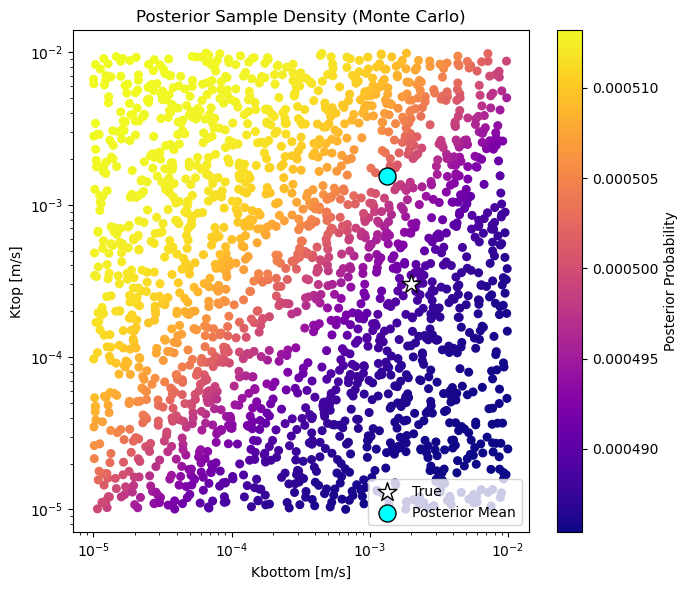

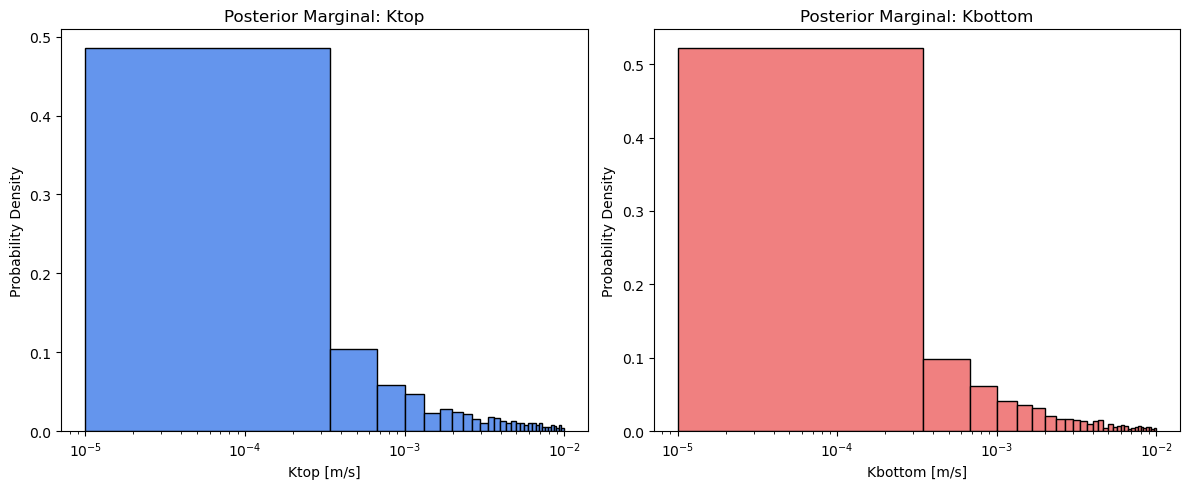

In [4]:
# --- Core model ---
def steady_state_head(K_layers, H_top, H_bottom):
    n = len(K_layers)
    dz = 1.0 / n
    R_total = np.sum(1.0 / (K_layers * dz))
    q = (H_top - H_bottom) / R_total
    h = np.zeros(n + 1)
    h[0] = H_top
    for i in range(n):
        dh = q * dz / K_layers[i]
        h[i + 1] = h[i] - dh
    return h

# --- Problem setup ---
H_top, H_bottom = 10.0, 0.0
Ktop_true, Kbottom_true = 3e-4, 2e-3
K_layers_true = np.array([Ktop_true]*5 + [Kbottom_true]*5)
h_true = steady_state_head(K_layers_true, H_top, H_bottom)
H3_true, H7_true = h_true[3], h_true[7]

# Add synthetic observation noise
np.random.seed(1)
noise_std = 0.05  # 5% noise
H3_obs = H3_true + np.random.normal(0, H3_true * noise_std)
H7_obs = H7_true + np.random.normal(0, H7_true * noise_std)

# --- RMSE function ---
def rmse_objective(Kpair):
    Ktop, Kbottom = Kpair
    if Ktop <= 0 or Kbottom <= 0:
        return 1e6
    K_layers = np.array([Ktop]*5 + [Kbottom]*5)
    h = steady_state_head(K_layers, H_top, H_bottom)
    return np.sqrt(((h[3] - H3_obs)**2 + (h[7] - H7_obs)**2) / 2)

# --- Monte Carlo posterior sampling ---
N = 2000
Ktop_samples = 10**np.random.uniform(-5, -2, N)
Kbottom_samples = 10**np.random.uniform(-5, -2, N)

RMSE = np.zeros(N)
for i in range(N):
    RMSE[i] = rmse_objective([Ktop_samples[i], Kbottom_samples[i]])

# Convert RMSE to likelihood (assuming Gaussian error model)
sigma = H3_true * noise_std
likelihood = np.exp(-0.5 * (RMSE / sigma)**2)

# Normalize to form a pseudo-posterior
posterior = likelihood / np.sum(likelihood)

# --- Weighted mean and covariance ---
Ktop_mean = np.sum(Ktop_samples * posterior)
Kbottom_mean = np.sum(Kbottom_samples * posterior)

cov_Ktop = np.sqrt(np.sum(posterior * (Ktop_samples - Ktop_mean)**2))
cov_Kbottom = np.sqrt(np.sum(posterior * (Kbottom_samples - Kbottom_mean)**2))

print("Posterior mean and 1σ uncertainty:")
print(f"Ktop ≈ {Ktop_mean:.2e} ± {cov_Ktop:.1e}")
print(f"Kbottom ≈ {Kbottom_mean:.2e} ± {cov_Kbottom:.1e}")

# --- Visualization ---
plt.figure(figsize=(7, 6))
sc = plt.scatter(Kbottom_samples, Ktop_samples, c=posterior, cmap='plasma', s=30)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Kbottom [m/s]')
plt.ylabel('Ktop [m/s]')
plt.title('Posterior Sample Density (Monte Carlo)')
plt.colorbar(sc, label='Posterior Probability')
plt.scatter(Kbottom_true, Ktop_true, color='white', edgecolor='black', marker='*', s=200, label='True')
plt.scatter(Kbottom_mean, Ktop_mean, color='cyan', edgecolor='black', marker='o', s=150, label='Posterior Mean')
plt.legend()
plt.tight_layout()
plt.show()

# --- Marginal distributions ---
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.hist(Ktop_samples, bins=30, weights=posterior, color='cornflowerblue', edgecolor='black')
plt.xscale('log')
plt.xlabel('Ktop [m/s]')
plt.ylabel('Probability Density')
plt.title('Posterior Marginal: Ktop')

plt.subplot(1,2,2)
plt.hist(Kbottom_samples, bins=30, weights=posterior, color='lightcoral', edgecolor='black')
plt.xscale('log')
plt.xlabel('Kbottom [m/s]')
plt.ylabel('Probability Density')
plt.title('Posterior Marginal: Kbottom')

plt.tight_layout()
plt.show()
